# Challenge 19 This is how it is worded in canvas I guess we skipped challenge 18, but this is where we will solve an ODE and using euler's forward, comparing it to the analytical solution and then 

/tmp/ipykernel_1570/1648276909.py:10: RuntimeWarning: overflow encountered in scalar multiply
  return -1000 * y + 3000 - 2000 * np.exp(-t)
/tmp/ipykernel_1570/1648276909.py:22: RuntimeWarning: invalid value encountered in scalar add
  y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])


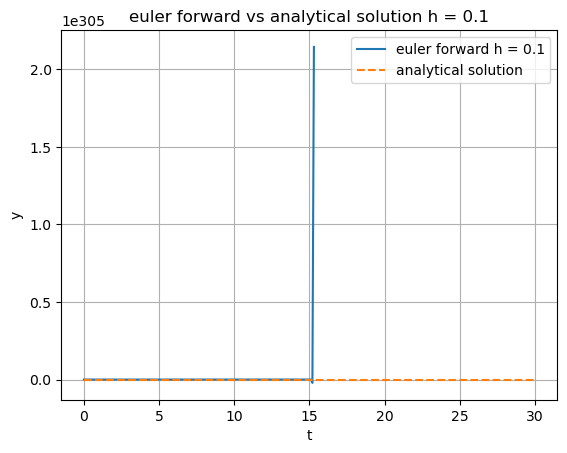

h = 0.1   max error = nan


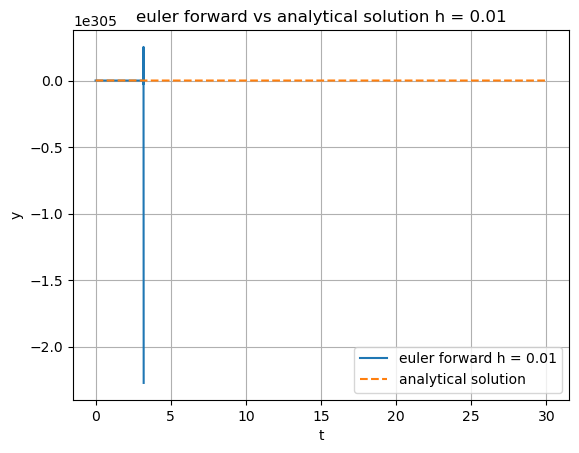

h = 0.01   max error = nan


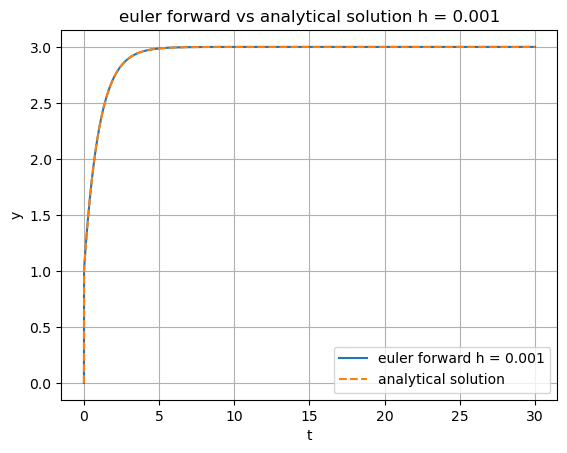

h = 0.001   max error = 0.367143


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import math
import time

t_start, t_end = 0, 30
step_sizes = [0.1, 0.01, 0.001]
 
def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)
 
def exact_solution(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)
 
for h in step_sizes:
    num_steps = int((t_end - t_start) / h)
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 0
 
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])
 
    y_exact = exact_solution(t_values)
 
    plt.figure()
    plt.plot(t_values, y_values, label=f"euler forward h = {h}")
    plt.plot(t_values, y_exact, linestyle="--", label="analytical solution")
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(f"euler forward vs analytical solution h = {h}")
    plt.legend()
    plt.grid(True)
    plt.show()
 
    print(f"h = {h}   max error = {np.max(np.abs(y_values - y_exact)):.6f}")
 

# I think this error is the point to see our graph blow up for h= 0.1 and 0.01 since we need a very small h value in order to satisfy our h<2/lambda which we could see if we were to solve for the eigen values and see that for very large eigen values, an ODE can be stiff